<a href="https://colab.research.google.com/github/mrushad/ml4qs-G39/blob/main/Final_random_forrest_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

In [29]:
# Operating System
import os
import shutil

# General
import pandas as pd
import numpy as np
import re
import warnings


# ML
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics  import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import train_test_split


# Plots
import matplotlib.pyplot as plt
import seaborn as sns

# Cloning github repo to access data

In [3]:
repo_dir = 'ml4qs-G39'
if os.path.isdir(repo_dir):
    shutil.rmtree(repo_dir)
    print(f"Removed existing directory: {repo_dir}")

Removed existing directory: ml4qs-G39


In [4]:
!git clone https://github.com/mrushad/ml4qs-G39

Cloning into 'ml4qs-G39'...
remote: Enumerating objects: 140, done.
remote: Counting objects: 100% (140/140), done.
remote: Compressing objects: 100% (132/132), done.
remote: Total 140 (delta 38), reused 36 (delta 5), pack-reused 0 (from 0)
Receiving objects: 100% (140/140), 32.73 MiB | 10.29 MiB/s, done.
Resolving deltas: 100% (38/38), done.


# Functions

## read_csv_files()

In [5]:
def read_csv_files():
  csv_files = [
      'Accelerometer.csv',
      'Linear Accelerometer.csv',
      'Barometer.csv',
      'Location.csv',
      'Gyroscope.csv',
      'Magnetometer.csv',
      'Proximity.csv'
  ]

  # Dictionary to store DataFrames
  dfs = {}

  for filename in csv_files:
      try:
          # Create a clean DataFrame name (e.g., 'Accelerometer_df')
          df_name = filename.replace('.csv', '') + '_df'

          # Read the CSV file
          df = pd.read_csv(filename)

          # Store it in the dictionary
          dfs[df_name] = df

          print(f"Loaded '{filename}' into DataFrame '{df_name}'. Shape: {df.shape}")
          # Optional: Display the first few rows to verify
          # print(dfs[df_name].head())

      except FileNotFoundError:
          print(f"Error: '{filename}' not found in the current directory ({os.getcwd()}).")
      except Exception as e:
          print(f"Error loading '{filename}': {e}")

  #for name, df in dfs.items():
      #print(f"DataFrame: {name}, Columns: {df.columns.tolist()}, Shape: {df.shape}")
  return dfs

## combine_dfs()

In [6]:
def combine_dfs(sensor_dfs):
    # Initialize an empty list to store processed DataFrames
    processed_dfs = []

    # Process each DataFrame
    for sensor_name, df in sensor_dfs.items(): # Iterate using the 'sensor_dfs' for cleaner prefixes
        # Create a copy to avoid modifying the original DataFrame directly
        df_copy = df.copy()

        # Round the 'Time (s)' column to three decimal places
        df_copy['Time (s)'] = df_copy['Time (s)'].round(2)

        # Rename columns to include the sensor name as a prefix
        new_columns = {}
        for col in df_copy.columns:
            if col != 'Time (s)':
                # Replace spaces in column names with underscores for consistency
                # Also remove parentheses from the unit part of the column name
                new_col_name = f"{sensor_name}_{col.replace(' ', '_').replace('(', '').replace(')', '')}"
                new_columns[col] = new_col_name
        df_copy = df_copy.rename(columns=new_columns)
        processed_dfs.append(df_copy) # Correctly append to 'processed_dfs'

    # Merge all processed DataFrames based on the 'Time (s)' column
    # Start with the first processed DataFrame
    if processed_dfs:
        combined_df = processed_dfs[0] # Use 'processed_dfs' for merging
        for i in range(1, len(processed_dfs)):
            combined_df = pd.merge(combined_df, processed_dfs[i], on='Time (s)', how='outer')

        # Display the combined DataFrame information
        #print("Combined DataFrame Head:")
        #print(combined_df.head())
        #print("\nCombined DataFrame Info:")
        #combined_df.info()
    else:
        print("No DataFrames to combine.")
    return combined_df

## identify_correlation()

In [7]:
def identify_correlation(df, correlation_method='spearman', correlation_threshold=0.6):
    # Select only numeric columns for correlation calculation
    numeric_df = df.select_dtypes(include=np.number)

    # Handle potential all-NaN columns after selection if necessary, though corr() usually handles this.

    correlation = numeric_df.corr(method=correlation_method)
    # correlation_threshold = 0.60  # This line is redundant as it's also a parameter

    print(f"Pairs with Strong Spearman Correlation (absolute value >= {correlation_threshold}):\n")
    num_cols = len(correlation.columns)
    found_strong_correlation = False

    for i in range(num_cols):
        for j in range(i + 1, num_cols):
            var1 = correlation.columns[i]
            var2 = correlation.columns[j]
            correlation_value = correlation.iloc[i, j]

            if abs(correlation_value) >= correlation_threshold:
                print(f"  {var1} vs {var2}: {correlation_value:.4f}")
                found_strong_correlation = True

    if not found_strong_correlation:
        print("  No pairs found with strong Spearman correlation above the threshold.")

In [8]:
def replicate_and_noise_dataframe(original_df, num_replications=1, noise_factor=0.01, numeric_cols_to_noise=None):
    """
    Replicates a DataFrame, adjusts session_ids, and adds noise to numerical columns.

    Args:
        original_df (pd.DataFrame): The original DataFrame with 'session_id' and 'activity' columns.
        num_replications (int): How many times to replicate the data.
                                (e.g., 1 means one copy, resulting in 2 dataframes total)
        noise_factor (float): Multiplier for the standard deviation to determine the noise level.
                              A higher value means more variance.
        numeric_cols_to_noise (list, optional): A list of column names to add noise to.
                                                If None, noise will be added to all numerical columns
                                                except 'session_id'.

    Returns:
        pd.DataFrame: A new DataFrame containing the original data and the replicated,
                      noised data.
    """

    replicated_dfs = [original_df.copy()]  # Start with the original dataframe

    # Determine numeric columns to apply noise to
    if numeric_cols_to_noise is None:
        numerical_columns = original_df.select_dtypes(include=np.number).columns.tolist()
        # Exclude 'session_id' from noise application
        if 'session_id' in numerical_columns:
            numerical_columns.remove('session_id')
        cols_to_noise = [col for col in numerical_columns if col != 'session_id']
    else:
        cols_to_noise = numeric_cols_to_noise

    max_original_session_id = original_df['session_id'].max()

    for i in range(num_replications):
        new_df = original_df.copy()

        # Update session_id: if original has 0-6, the first replica will have 7-13
        # We assume session_ids are contiguous and start from 0 or 1.
        # If your session_ids are not contiguous, you might need a different mapping.
        session_id_offset = (i + 1) * (max_original_session_id + 1)
        new_df['session_id'] = original_df['session_id'] + session_id_offset

        # Add noise to numerical columns
        for col in cols_to_noise:
            if col in new_df.columns:
                # Calculate the standard deviation of the column
                std_dev = original_df[col].std()
                if pd.isna(std_dev) or std_dev == 0:
                    # If std_dev is NaN or 0 (e.g., column has all same values),
                    # use a small fixed value or skip noise for this column
                    noise_amount = 0.01 * original_df[col].mean() if original_df[col].mean() != 0 else 0.01
                else:
                    noise_amount = std_dev * noise_factor

                # Add random noise from a normal distribution
                noise = np.random.normal(0, noise_amount, size=len(new_df))
                new_df[col] = new_df[col] + noise

                # Optional: Ensure values don't go negative if they represent physical quantities
                # For example, if acceleration can't be negative, uncomment the line below:
                # new_df[col] = new_df[col].apply(lambda x: max(0, x))


        replicated_dfs.append(new_df)

    # Concatenate all dataframes
    final_df = pd.concat(replicated_dfs, ignore_index=True)
    return final_df

# Get all csvs & put them all in one df & add activity & session columns

In [9]:
total_df = pd.DataFrame()
# Get the list of all directories in the current working directory
os.chdir('ml4qs-G39/data/raw')
current_directory_contents = os.listdir('.')
os.listdir('.')

['Metro2 2025-06-19 17-05-44',
 'BikingData1 2025-06-06 10-48-07',
 'Metro1 2025-06-19 14-43-22',
 'DrivingData3 2025-06-19 15-40-50',
 'DrivingData2 2025-06-19 14-30-43',
 'WalkingData1 2025-06-06 15-30-08',
 'DrivingData1 2025-06-19 19-26-19']

In [10]:
directories_to_process = [d for d in current_directory_contents if os.path.isdir(d)]

# Store the original working directory
original_wd = os.getcwd()

if not directories_to_process:
    print("No directories found in the current working directory to process.")
else:
    for directory in directories_to_process:
        print(f"\nProcessing directory: {directory}")



Processing directory: Metro2 2025-06-19 17-05-44

Processing directory: BikingData1 2025-06-06 10-48-07

Processing directory: Metro1 2025-06-19 14-43-22

Processing directory: DrivingData3 2025-06-19 15-40-50

Processing directory: DrivingData2 2025-06-19 14-30-43

Processing directory: WalkingData1 2025-06-06 15-30-08

Processing directory: DrivingData1 2025-06-19 19-26-19


In [11]:
total_df = pd.DataFrame()
# Get the list of all directories in the current working directory
current_directory_contents = os.listdir('.')
directories_to_process = [d for d in current_directory_contents if os.path.isdir(d)]

# Store the original working directory
original_wd = os.getcwd()
counter = 0
if not directories_to_process:
    print("No directories found in the current working directory to process.")
else:
    for directory in directories_to_process:
        print(f"\nProcessing directory: {directory}")
        try:
            os.chdir(directory)
            print(f"  Changed directory to: {os.getcwd()}")

            dfs = read_csv_files()

            # --- START: Add activity column logic here ---
            activity = None
            # This regex looks for 'Biking', 'Driving', 'Metro', or 'Walking' (case-insensitive)
            # It also handles "Data1", "Data2", or just the name (e.g., "Metro1", "Metro2")
            match = re.search(r'(Biking|Driving|Metro|Walking)', directory, re.IGNORECASE)
            if match:
                activity = match.group(1).capitalize() # Capitalize the matched activity (e.g., 'biking' -> 'Biking')
                print(f"  Detected activity: '{activity}' from directory name: '{directory}'")
            else:
                print(f"  Warning: Could not determine activity type from directory name: '{directory}'. 'activity' column might be missing or empty for this data.")



            # Check if any dataframes were read before combining
            if dfs:
                combined_df = combine_dfs(dfs)
                #print(f"\n  Head of combined dataframe for {directory}:")
                # print(combined_df.head())
                # --- START: Add activity column logic here ---
                activity = None
                # This regex looks for 'Biking', 'Driving', 'Metro', or 'Walking' (case-insensitive)
                # It also handles "Data1", "Data2", or just the name (e.g., "Metro1", "Metro2")
                match = re.search(r'(Biking|Driving|Metro|Walking)', directory, re.IGNORECASE)
                if match:
                    activity = match.group(1).capitalize() # Capitalize the matched activity (e.g., 'biking' -> 'Biking')
                    print(f"  Detected activity: '{activity}' from directory name: '{directory}'")
                    combined_df['activity'] = activity
                    combined_df['session_id'] = counter
                    counter += 1
                else:
                    print(f"  Warning: Could not determine activity type from directory name: '{directory}'. 'activity' column might be missing or empty for this data.")
                total_df = pd.concat([total_df, combined_df], ignore_index=True)
            else:
                print(f"  No CSV files found or read in {directory}.")

        except Exception as e:
            print(f"  An error occurred while processing {directory}: {e}")
        finally:
            # Always change back to the original working directory
            os.chdir(original_wd)
            print(f"  Changed back to original directory: {os.getcwd()}")


Processing directory: Metro2 2025-06-19 17-05-44
  Changed directory to: /content/ml4qs-G39/data/raw/Metro2 2025-06-19 17-05-44
Loaded 'Accelerometer.csv' into DataFrame 'Accelerometer_df'. Shape: (90405, 4)
Loaded 'Linear Accelerometer.csv' into DataFrame 'Linear Accelerometer_df'. Shape: (90402, 4)
Loaded 'Barometer.csv' into DataFrame 'Barometer_df'. Shape: (905, 2)
Loaded 'Location.csv' into DataFrame 'Location_df'. Shape: (900, 8)
Loaded 'Gyroscope.csv' into DataFrame 'Gyroscope_df'. Shape: (90402, 4)
Loaded 'Magnetometer.csv' into DataFrame 'Magnetometer_df'. Shape: (90402, 4)
Loaded 'Proximity.csv' into DataFrame 'Proximity_df'. Shape: (1, 2)
  Detected activity: 'Metro' from directory name: 'Metro2 2025-06-19 17-05-44'
  Detected activity: 'Metro' from directory name: 'Metro2 2025-06-19 17-05-44'
  Changed back to original directory: /content/ml4qs-G39/data/raw

Processing directory: BikingData1 2025-06-06 10-48-07
  Changed directory to: /content/ml4qs-G39/data/raw/BikingData

/tmp/ipython-input-11-2537650266.py:51: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  total_df = pd.concat([total_df, combined_df], ignore_index=True)


  Detected activity: 'Driving' from directory name: 'DrivingData2 2025-06-19 14-30-43'


/tmp/ipython-input-11-2537650266.py:51: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  total_df = pd.concat([total_df, combined_df], ignore_index=True)


  Changed back to original directory: /content/ml4qs-G39/data/raw

Processing directory: WalkingData1 2025-06-06 15-30-08
  Changed directory to: /content/ml4qs-G39/data/raw/WalkingData1 2025-06-06 15-30-08
Loaded 'Accelerometer.csv' into DataFrame 'Accelerometer_df'. Shape: (90423, 4)
Loaded 'Linear Accelerometer.csv' into DataFrame 'Linear Accelerometer_df'. Shape: (90423, 4)
Loaded 'Barometer.csv' into DataFrame 'Barometer_df'. Shape: (847, 2)
Loaded 'Location.csv' into DataFrame 'Location_df'. Shape: (899, 8)
Loaded 'Gyroscope.csv' into DataFrame 'Gyroscope_df'. Shape: (90423, 4)
Loaded 'Magnetometer.csv' into DataFrame 'Magnetometer_df'. Shape: (90423, 4)
Loaded 'Proximity.csv' into DataFrame 'Proximity_df'. Shape: (1, 2)
  Detected activity: 'Walking' from directory name: 'WalkingData1 2025-06-06 15-30-08'
  Detected activity: 'Walking' from directory name: 'WalkingData1 2025-06-06 15-30-08'
  Changed back to original directory: /content/ml4qs-G39/data/raw

Processing directory: 

/tmp/ipython-input-11-2537650266.py:51: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  total_df = pd.concat([total_df, combined_df], ignore_index=True)


In [12]:
total_df['activity'].unique()

array(['Metro', 'Biking', 'Driving', 'Walking'], dtype=object)

In [13]:
total_df['session_id'].unique()

array([0, 1, 2, 3, 4, 5, 6])

# Cleaning

## Filling Nulls using interpolaration

In [14]:
total_df.isnull().sum()

,0
Time (s),0
Accelerometer_df_X_m/s^2,5874
Accelerometer_df_Y_m/s^2,5874
Accelerometer_df_Z_m/s^2,5874
Linear Accelerometer_df_X_m/s^2,5878
Linear Accelerometer_df_Y_m/s^2,5878
Linear Accelerometer_df_Z_m/s^2,5878
Barometer_df_X_hPa,376975
Location_df_Latitude_°,376847
Location_df_Longitude_°,376847


In [15]:
# Interpolate all columns in total_df
for col in total_df.columns:
    if total_df[col].isnull().any():
        total_df[col] = total_df.groupby('session_id')[col].transform(lambda group: group.interpolate(method='linear'))
print("Interpolation complete for total_df:")
print(total_df.isnull().sum())

Interpolation complete for total_df:
Time (s)                                      0
Accelerometer_df_X_m/s^2                   5874
Accelerometer_df_Y_m/s^2                   5874
Accelerometer_df_Z_m/s^2                   5874
Linear Accelerometer_df_X_m/s^2            5878
Linear Accelerometer_df_Y_m/s^2            5878
Linear Accelerometer_df_Z_m/s^2            5878
Barometer_df_X_hPa                         5869
Location_df_Latitude_°                     4613
Location_df_Longitude_°                    4613
Location_df_Height_m                       4613
Location_df_Velocity_m/s                   4793
Location_df_Direction_°                    5001
Location_df_Horizontal_Accuracy_m          4613
Location_df_Vertical_Accuracy_°            6121
Gyroscope_df_X_rad/s                       5878
Gyroscope_df_Y_rad/s                       5878
Gyroscope_df_Z_rad/s                       5878
Magnetometer_df_X_µT                       5878
Magnetometer_df_Y_µT                       5878
Mag

# Analyze Correlation

In [16]:
identify_correlation(total_df)

Pairs with Strong Spearman Correlation (absolute value >= 0.6):

  Time (s) vs Accelerometer_df_Acceleration_z_m/s^2: -0.6046
  Time (s) vs Location_df_Vertical_Accuracy_m: -0.9473
  Time (s) vs Magnetometer_df_Magnetic_field_x_µT: -0.8483
  Time (s) vs Magnetometer_df_Magnetic_field_z_µT: 0.6254
  Accelerometer_df_Y_m/s^2 vs Accelerometer_df_Z_m/s^2: -0.6065
  Accelerometer_df_Y_m/s^2 vs Proximity_df_Distance_cm: -0.6873
  Barometer_df_X_hPa vs Location_df_Latitude_°: -0.7653
  Barometer_df_X_hPa vs Location_df_Longitude_°: 0.6188
  Barometer_df_X_hPa vs Proximity_df_Distance_cm: 0.7399
  Location_df_Latitude_° vs Location_df_Longitude_°: -0.6128
  Location_df_Latitude_° vs Proximity_df_Distance_cm: -0.7381
  Location_df_Latitude_° vs Location_df_Vertical_Accuracy_m: 0.9473
  Location_df_Longitude_° vs Location_df_Vertical_Accuracy_m: -0.9473
  Location_df_Height_m vs session_id: -0.6780
  Location_df_Direction_° vs session_id: -0.6350
  session_id vs Accelerometer_df_Acceleration_y_m

# Feature Engineering

## Time Based

In [17]:
## TODO using meta data (in meta folder) calculate time of day

## Linear Acceleration


In [18]:
def calculate_linear_acceleration_magnitude(df):
  # Total Linear Acceleration Magnitude
  df['linear_acceleration_magnitude_m/s^2'] = np.sqrt(
      df['Linear Accelerometer_df_X_m/s^2']**2 +
      df['Linear Accelerometer_df_Y_m/s^2']**2 +
      df['Linear Accelerometer_df_Z_m/s^2']**2
  )
  return df

total_df = calculate_linear_acceleration_magnitude(total_df)

## Turning Rate / Change in Direction

In [19]:
def calculate_turning_rate(df):
  # Turning Rate / Change in Direction
  # Handle circular nature of degrees (0-360)
  df['direction_diff_deg'] = df['Location_df_Direction_°'].diff().apply(
      lambda x: (x + 180) % 360 - 180 if pd.notna(x) else x
  )
  df['dt_s'] = df['Time (s)'].diff()
  df['turning_rate_deg/s'] = df['direction_diff_deg'] / df['dt_s']
  df['absolute_turning_rate_deg/s'] = df['turning_rate_deg/s'].abs()
  return df

total_df = calculate_turning_rate(total_df)

## Acceleration from GPS

In [20]:
def calculate_gps_acceleration(df):
  # Acceleration from GPS
  df['gps_acceleration_m/s^2'] = df['Location_df_Velocity_m/s'].diff() / df['dt_s']
  return df

total_df = calculate_gps_acceleration(total_df)

In [21]:
total_df.columns

Index(['Time (s)', 'Accelerometer_df_X_m/s^2', 'Accelerometer_df_Y_m/s^2',
       'Accelerometer_df_Z_m/s^2', 'Linear Accelerometer_df_X_m/s^2',
       'Linear Accelerometer_df_Y_m/s^2', 'Linear Accelerometer_df_Z_m/s^2',
       'Barometer_df_X_hPa', 'Location_df_Latitude_°',
       'Location_df_Longitude_°', 'Location_df_Height_m',
       'Location_df_Velocity_m/s', 'Location_df_Direction_°',
       'Location_df_Horizontal_Accuracy_m', 'Location_df_Vertical_Accuracy_°',
       'Gyroscope_df_X_rad/s', 'Gyroscope_df_Y_rad/s', 'Gyroscope_df_Z_rad/s',
       'Magnetometer_df_X_µT', 'Magnetometer_df_Y_µT', 'Magnetometer_df_Z_µT',
       'Proximity_df_Distance_cm', 'activity', 'session_id',
       'Accelerometer_df_Acceleration_x_m/s^2',
       'Accelerometer_df_Acceleration_y_m/s^2',
       'Accelerometer_df_Acceleration_z_m/s^2',
       'Location_df_Vertical_Accuracy_m', 'Gyroscope_df_Gyroscope_x_rad/s',
       'Gyroscope_df_Gyroscope_y_rad/s', 'Gyroscope_df_Gyroscope_z_rad/s',
       'Ma

# Resampling

In [ ]:
# COMMON_COLS = total_df.columns.tolist()
# TARGET_HZ = 50

In [ ]:
#def prep_session(df_single_session, label, session_id):
#    """
#    Preprocesses a DataFrame representing a single session.
#    This function's core logic remains largely the same, but arguments are clarified.
#
#    Args:
#        df_single_session (pd.DataFrame): DataFrame for a single session.
#        label (str): The activity label for this session.
#        session_id (int/str): The ID of this session.
#
#    Returns:
#        pd.DataFrame: The preprocessed DataFrame for the single session.
#    """
#    df = df_single_session.copy()
#
#    # 1️⃣ turn "seconds-since-start" into a TimedeltaIndex
#    # Assuming 'Time (s)' is the column with time in seconds from the start of the session.
#    df['rel_time'] = pd.to_timedelta(df['Time (s)'], unit='s')
#    df = df.set_index('rel_time')
#
#    # Exclude non-numeric columns and identifier columns before resampling
#    # Get all numeric columns
#    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
#
#    # Explicitly exclude 'session_id' even if it's numeric (though it shouldn't be averaged)
#    # Also exclude 'Time (s)' as it's used for the index
#    cols_to_resample = [
#        col for col in numeric_cols
#        if col != 'Time (s)' and col != 'session_id'
#    ]
#
#    # Ensure the activity column is NOT included in the columns to resample/mean
#    if 'activity' in df.columns and 'activity' in cols_to_resample:
#        cols_to_resample.remove('activity') # Defensive check, should not happen if only include=np.number
#
#    df_numeric = df[cols_to_resample] # Select only the columns that are numeric and not identifiers
#
#    # 2️⃣ NOW resample works
#    ms_per_sample = int(1000 / TARGET_HZ)  # e.g. 20 ms for 50 Hz
#    # Apply mean only to the numeric columns selected
#    df_resampled = df_numeric.resample(f'{ms_per_sample}ms').mean()
#
#    # Replace infinite values with NaN and interpolate
#    df_resampled = df_resampled.replace([np.inf, -np.inf], np.nan).interpolate()
#
#    # Handle cases where interpolation might leave NaNs at the start/end if they were originally NaNs
#    # This is a good practice if you expect leading/trailing NaNs
#    df_resampled = df_resampled.fillna(method='ffill').fillna(method='bfill')
#
#
#    # restore a simple row index (optional)
#    df_resampled = df_resampled.reset_index(drop=True)
#
#    # Add back activity and session_id columns (these are constant within a session chunk)
#    # Using fillna(method='ffill').fillna(method='bfill') after reset_index
#    # will correctly propagate these values if they were part of the original df_numeric
#    # but it's safer and clearer to add them explicitly.
#    df_resampled['activity'] = label
#    df_resampled['session_id'] = session_id
#
#
#    # keep only the columns you want, in order
#    # We need to rebuild the final column order dynamically as the resampled columns
#    # are only the numeric ones we selected for resampling.
#    final_cols_order = cols_to_resample + ['activity', 'session_id']
#    # Ensure all columns in final_cols_order are actually in df_resampled before reordering
#    final_cols_order = [col for col in final_cols_order if col in df_resampled.columns]
#    df_resampled = df_resampled[final_cols_order]
#
#    return df_resampled

In [ ]:
#def prep_multi_session_df(df_all_sessions, session_id_column='session_id', activity_column='activity', target_hz=50):
#    """
#    Preprocesses a DataFrame containing multiple sessions by applying
#    the prep_session logic to each session independently.
#
#    Args:
#        df_all_sessions (pd.DataFrame): The input DataFrame with 'session_id' and 'activity' columns.
#        session_id_column (str): The name of the column containing session IDs.
#        activity_column (str): The name of the column containing activity labels.
#        target_hz (int): The target sampling frequency in Hz.
#
#    Returns:
#        pd.DataFrame: A new DataFrame with all sessions preprocessed and concatenated.
#    """
#    global TARGET_HZ # Make TARGET_HZ accessible within this function if it's a global
#    TARGET_HZ = target_hz
#
#    processed_sessions = []
#
#    # Group by session ID and activity to get individual session data
#    # Assuming each session_id uniquely corresponds to one activity label
#    for (session_id, activity_label), session_df in df_all_sessions.groupby([session_id_column, activity_column]):
#        print(f"Preprocessing Session ID: {session_id}, Activity: {activity_label}")
#        prepped_df = prep_session(session_df, activity_label, session_id)
#        processed_sessions.append(prepped_df)
#
#    # Concatenate all processed sessions into a single DataFrame
#    if processed_sessions:
#        return pd.concat(processed_sessions, ignore_index=True)
#    else:
#        return pd.DataFrame(columns=[col for col in COMMON_COLS if col != 'Time (s)'] + ['activity', 'session_id']) # Return empty DF with correct columns
#
#total_df = prep_multi_session_df(total_df)

Preprocessing Session ID: 0, Activity: Metro


/tmp/ipython-input-85-1529504895.py:48: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_resampled = df_resampled.fillna(method='ffill').fillna(method='bfill')


Preprocessing Session ID: 1, Activity: Biking


/tmp/ipython-input-85-1529504895.py:48: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_resampled = df_resampled.fillna(method='ffill').fillna(method='bfill')


Preprocessing Session ID: 2, Activity: Metro


/tmp/ipython-input-85-1529504895.py:48: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_resampled = df_resampled.fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-85-1529504895.py:48: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_resampled = df_resampled.fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-85-1529504895.py:48: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_resampled = df_resampled.fillna(method='ffill').fillna(method='bfill')


Preprocessing Session ID: 3, Activity: Driving
Preprocessing Session ID: 4, Activity: Driving
Preprocessing Session ID: 5, Activity: Walking
Preprocessing Session ID: 6, Activity: Driving


/tmp/ipython-input-85-1529504895.py:48: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_resampled = df_resampled.fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-85-1529504895.py:48: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_resampled = df_resampled.fillna(method='ffill').fillna(method='bfill')


In [22]:
saved = total_df.copy()

In [23]:
total_df = saved.copy()

# Add fake data

In [24]:
total_df = replicate_and_noise_dataframe(total_df, noise_factor=1.2, num_replications=2)

/usr/local/lib/python3.11/dist-packages/numpy/_core/_methods.py:52: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/usr/local/lib/python3.11/dist-packages/numpy/_core/_methods.py:52: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


In [25]:
total_df['session_id'].unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20])

# Normal Random Split

In [27]:
total_df = total_df.drop(columns=['Proximity_df_Distance_cm', 'Location_df_Height_m', 'Location_df_Latitude_°'])

KeyError: "['Proximity_df_Distance_cm', 'Location_df_Height_m', 'Location_df_Latitude_°'] not found in axis"

# A few different classifications

In [ ]:
# Suppress ConvergenceWarning for Logistic Regression, as it's common for default solver
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

feature_columns = [col for col in total_df.columns if col not in ['Time (s)', 'activity', 'session_id', 'dt_s', 'direction_diff_deg']]
X = total_df[feature_columns]
y = total_df['activity']


print("Using a single random train-test split.")
print("Generating split and performing classification...")

# Get all possible labels from the entire dataset once for consistent plotting
all_possible_labels = sorted(total_df['activity'].unique())

# --- Perform a single random train-test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"\nTrain set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

# --- Diagnostic: Class distribution in the single split ---
print("\n  Class distribution in y_train:")
print(y_train.value_counts(normalize=True).sort_index())
print(f"  Unique classes in y_train: {np.unique(y_train)}")

print("\n  Class distribution in y_test:")
print(y_test.value_counts(normalize=True).sort_index())
print(f"  Unique classes in y_test: {np.unique(y_test)}")


# --- Data Cleaning for Training Data ---
# 1. Replace infinities with NaN
X_train.replace([np.inf, -np.inf], np.nan, inplace=True)

# 2. Convert extremely large finite values to NaN
cap_threshold = 1e10
X_train[X_train > cap_threshold] = np.nan
X_train[X_train < -cap_threshold] = np.nan

# Ensure all feature columns are of a float type to correctly hold NaNs
# Fill NaNs with the mean of the column. A more sophisticated imputation strategy
# might be needed for real-world data (e.g., KNNImputer, IterativeImputer).
# For simplicity here, we use mean imputation.
X_train_final = X_train.astype(float).fillna(X_train.mean())


# --- Data Cleaning for Test Data ---
X_test.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test[X_test > cap_threshold] = np.nan
X_test[X_test < -cap_threshold] = np.nan

# Fill NaNs in test set using the means *from the training set* to prevent data leakage.
X_test_final = X_test.astype(float).fillna(X_train.mean()) # Use X_train's mean here


# Sanity check: Ensure train and test dataframes have the same columns
if not X_train_final.columns.equals(X_test_final.columns):
    raise ValueError("Train and Test dataframes do not have matching columns after initial NaN/inf handling.")


def run_classification_models(X_train, X_test, y_train, y_test, labels):
    """
    Trains and evaluates multiple classification models, prints classification reports,
    and displays confusion matrices with distinct colors.

    Args:
        X_train (pd.DataFrame): Training features.
        X_test (pd.DataFrame): Test features.
        y_train (pd.Series): Training target variable.
        y_test (pd.Series): Test target variable.
        labels (list): All possible unique class labels for consistent plotting.
    """
    classifiers = {
        "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
        "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42, solver='liblinear', class_weight='balanced'),
        "SVM (SVC)": SVC(kernel='linear', random_state=42, class_weight='balanced'),
        "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5)
    }

    # Define a list of color maps to use for confusion matrices
    cmaps = ['Blues', 'Reds', 'Greens', 'Purples']
    cmap_index = 0

    for name, classifier in classifiers.items():
        print(f"\n--- Training {name} ---")
        try:
            classifier.fit(X_train, y_train)
            y_pred = classifier.predict(X_test)

            print(f"\nClassification Report for {name}:\n")
            print(classification_report(y_test, y_pred, labels=labels, zero_division=0))

            # Calculate and display confusion matrix
            cm = confusion_matrix(y_test, y_pred, labels=labels)
            print(f"\nConfusion Matrix for {name}:\n{cm}")

            disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
            plt.figure(figsize=(8, 8)) # Create a new figure for each plot
            disp.plot(cmap=plt.get_cmap(cmaps[cmap_index % len(cmaps)])) # Cycle through cmaps
            plt.title(f'Confusion Matrix ({name})')
            plt.show()

            cmap_index += 1 # Move to the next color map
        except Exception as e:
            print(f"An error occurred during {name} training or prediction: {e}")
            print("Skipping this model.")

# Run the function with the prepared data
print("\n--- Running Classification Models ---")
run_classification_models(X_train_final, X_test_final, y_train, y_test, all_possible_labels)

print("\nAll classification tasks complete.")

Using a single random train-test split.
Generating split and performing classification...

Train set size: 799209
Test set size: 342519

  Class distribution in y_train:
activity
Biking     0.245506
Driving    0.015421
Metro      0.493712
Walking    0.245360
Name: proportion, dtype: float64
  Unique classes in y_train: ['Biking' 'Driving' 'Metro' 'Walking']

  Class distribution in y_test:
activity
Biking     0.245508
Driving    0.015421
Metro      0.493713
Walking    0.245359
Name: proportion, dtype: float64
  Unique classes in y_test: ['Biking' 'Driving' 'Metro' 'Walking']

--- Running Classification Models ---

--- Training Random Forest ---


Using a single random train-test split.
Generating split and performing classification...

Train set size: 799209
Test set size: 342519

  Class distribution in y_train:
activity
Biking     0.245506
Driving    0.015421
Metro      0.493712
Walking    0.245360
Name: proportion, dtype: float64
  Unique classes in y_train: ['Biking' 'Driving' 'Metro' 'Walking']

  Class distribution in y_test:
activity
Biking     0.245508
Driving    0.015421
Metro      0.493713
Walking    0.245359
Name: proportion, dtype: float64
  Unique classes in y_test: ['Biking' 'Driving' 'Metro' 'Walking']

Training Random Forest Classifier...
Training complete.

Confusion Matrix:
[[ 67635      0  11653   4803]
 [     0   5282      0      0]
 [  5693      0 154966   8447]
 [  5562      0  18995  59483]]


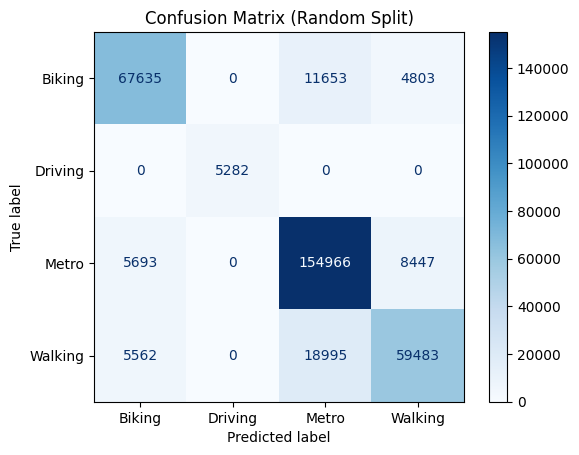


Classification with Random Split complete.


In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split # Changed from TimeSeriesSplit
import matplotlib.pyplot as plt
import numpy as np

feature_columns = [col for col in total_df.columns if col not in ['Time (s)', 'activity', 'session_id', 'dt_s', 'direction_diff_deg']]
X = total_df[feature_columns]
y = total_df['activity']


print("Using a single random train-test split.")
print("Generating split and performing classification...")

# Get all possible labels from the entire dataset once for consistent plotting
all_possible_labels = sorted(total_df['activity'].unique())

# --- Perform a single random train-test split ---
# test_size: proportion of the dataset to include in the test split
# random_state: for reproducibility
# stratify: Ensures that the proportion of classes in y is the same in both train and test sets.
#           Highly recommended for classification problems with imbalanced classes.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"\nTrain set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

# --- Diagnostic: Class distribution in the single split ---
print("\n  Class distribution in y_train:")
print(y_train.value_counts(normalize=True).sort_index())
print(f"  Unique classes in y_train: {np.unique(y_train)}")

print("\n  Class distribution in y_test:")
print(y_test.value_counts(normalize=True).sort_index())
print(f"  Unique classes in y_test: {np.unique(y_test)}")


# --- Data Cleaning for Training Data ---
# 1. Replace infinities with NaN
X_train.replace([np.inf, -np.inf], np.nan, inplace=True)

# 2. Convert extremely large finite values to NaN
cap_threshold = 1e10
X_train[X_train > cap_threshold] = np.nan
X_train[X_train < -cap_threshold] = np.nan

# Ensure all feature columns are of a float type to correctly hold NaNs
X_train_final = X_train.astype(float)


# --- Data Cleaning for Test Data ---
X_test.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test[X_test > cap_threshold] = np.nan
X_test[X_test < -cap_threshold] = np.nan

X_test_final = X_test.astype(float)


# Sanity check: Ensure train and test dataframes have the same columns
if not X_train_final.columns.equals(X_test_final.columns):
    raise ValueError("Train and Test dataframes do not have matching columns after initial NaN/inf handling.")

# Initialize and train the Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
print("\nTraining Random Forest Classifier...")
rf_classifier.fit(X_train_final, y_train)
print("Training complete.")

# Make predictions on the test set
y_pred = rf_classifier.predict(X_test_final)

# Calculate and print confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=all_possible_labels)
print(f"\nConfusion Matrix:\n{cm}")

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=all_possible_labels)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix (Random Split)')
plt.show()

print("\nClassification with Random Split complete.")


Accuracy: 0.8390
Precision (weighted): 0.8388
Recall (weighted): 0.8390
F1-Score (weighted): 0.8367

Classification Report:
              precision    recall  f1-score   support

      Biking       0.86      0.80      0.83     84091
     Driving       1.00      1.00      1.00      5282
       Metro       0.83      0.92      0.87    169106
     Walking       0.82      0.71      0.76     84040

    accuracy                           0.84    342519
   macro avg       0.88      0.86      0.87    342519
weighted avg       0.84      0.84      0.84    342519


Confusion Matrix:
[[ 67635      0  11653   4803]
 [     0   5282      0      0]
 [  5693      0 154966   8447]
 [  5562      0  18995  59483]]


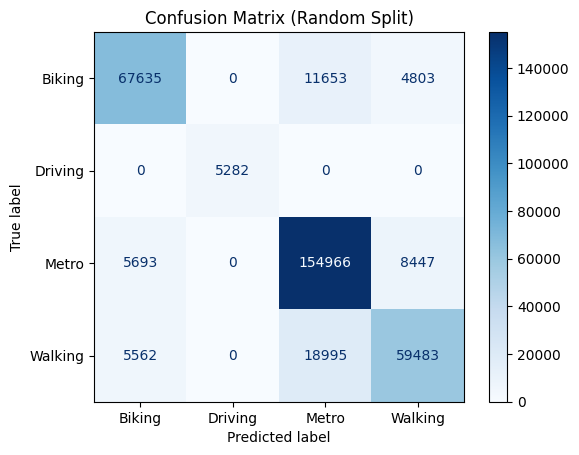


Classification with Random Split complete.


In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.4f}")

# Calculate and print precision, recall, and F1-score (for multi-class, use 'weighted' or 'macro' average)
# 'weighted' accounts for class imbalance
# 'macro' treats all classes equally
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Precision (weighted): {precision:.4f}")
print(f"Recall (weighted): {recall:.4f}")
print(f"F1-Score (weighted): {f1:.4f}")

# Print a full classification report for more detailed metrics per class
print("\nClassification Report:")
print(classification_report(y_test, y_pred, labels=all_possible_labels, zero_division=0)) # Added zero_division=0 to handle cases where a class has no predicted samples


# Calculate and print confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=all_possible_labels)
print(f"\nConfusion Matrix:\n{cm}")

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=all_possible_labels)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix (Random Split)')
plt.show()

print("\nClassification with Random Split complete.")

In [ ]:
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier # Changed to GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

# Define feature columns, excluding identifier and target columns
feature_columns = [col for col in total_df.columns if col not in ['Time (s)', 'activity', 'session_id', 'dt_s', 'direction_diff_deg']]
X = total_df[feature_columns]
y = total_df['activity']


print("Using a single random train-test split.")
print("Generating split and performing classification with Gradient Boosting...")

# Get all possible labels from the entire dataset once for consistent plotting
all_possible_labels = sorted(total_df['activity'].unique())

# --- Perform a single random train-test split ---
# test_size: proportion of the dataset to include in the test split
# random_state: for reproducibility
# stratify: Ensures that the proportion of classes in y is the same in both train and test sets.
#           Highly recommended for classification problems with imbalanced classes.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"\nTrain set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

# --- Diagnostic: Class distribution in the single split ---
print("\n  Class distribution in y_train:")
print(y_train.value_counts(normalize=True).sort_index())
print(f"  Unique classes in y_train: {np.unique(y_train)}")

print("\n  Class distribution in y_test:")
print(y_test.value_counts(normalize=True).sort_index())
print(f"  Unique classes in y_test: {np.unique(y_test)}")


# --- Data Cleaning for Training Data ---
# 1. Replace infinities with NaN
X_train.replace([np.inf, -np.inf], np.nan, inplace=True)

# 2. Convert extremely large finite values to NaN
cap_threshold = 1e10
X_train[X_train > cap_threshold] = np.nan
X_train[X_train < -cap_threshold] = np.nan

# Ensure all feature columns are of a float type to correctly hold NaNs
X_train_final = X_train.astype(float)


# --- Data Cleaning for Test Data ---
X_test.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test[X_test > cap_threshold] = np.nan
X_test[X_test < -cap_threshold] = np.nan

X_test_final = X_test.astype(float)

# IMPORTANT: Handle NaN values after cleaning for both train and test sets.
# GradientBoostingClassifier, unlike RandomForest, does not inherently handle NaNs.
# A common strategy is to impute them, e.g., with the mean or median.
# For simplicity, we'll use mean imputation here.
# It's crucial to fit the imputer ONLY on the training data and then transform both train and test sets.
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')

# Fit imputer on training data and transform
X_train_imputed = imputer.fit_transform(X_train_final)
X_train_imputed_df = pd.DataFrame(X_train_imputed, columns=X_train_final.columns, index=X_train_final.index)

# Transform test data using the *same* imputer fitted on training data
X_test_imputed = imputer.transform(X_test_final)
X_test_imputed_df = pd.DataFrame(X_test_imputed, columns=X_test_final.columns, index=X_test_final.index)


# Sanity check: Ensure train and test dataframes have the same columns
if not X_train_imputed_df.columns.equals(X_test_imputed_df.columns):
    raise ValueError("Train and Test dataframes do not have matching columns after imputation.")


# Initialize and train the Gradient Boosting Classifier
# n_estimators: The number of boosting stages to perform.
# learning_rate: Shrinks the contribution of each tree.
# random_state: For reproducibility.
# GradientBoostingClassifier does not have a direct `class_weight` parameter like RandomForest.
# For imbalanced classes, consider using techniques like SMOTE or adjusting sample weights if needed.
gb_classifier = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
print("\nTraining Gradient Boosting Classifier...")
gb_classifier.fit(X_train_imputed_df, y_train)
print("Training complete.")

# Make predictions on the test set
y_pred_gb = gb_classifier.predict(X_test_imputed_df)

# Calculate and print confusion matrix
cm_gb = confusion_matrix(y_test, y_pred_gb, labels=all_possible_labels)
print(f"\nConfusion Matrix (Gradient Boosting):\n{cm_gb}")

disp_gb = ConfusionMatrixDisplay(confusion_matrix=cm_gb, display_labels=all_possible_labels)
disp_gb.plot(cmap=plt.cm.Greens) # Using a different colormap for distinction
plt.title('Confusion Matrix (Gradient Boosting, Random Split)')
plt.show()

print("\nClassification with Gradient Boosting and Random Split complete.")

Using a single random train-test split.
Generating split and performing classification with Gradient Boosting...

Train set size: 799209
Test set size: 342519

  Class distribution in y_train:
activity
Biking     0.245506
Driving    0.015421
Metro      0.493712
Walking    0.245360
Name: proportion, dtype: float64
  Unique classes in y_train: ['Biking' 'Driving' 'Metro' 'Walking']

  Class distribution in y_test:
activity
Biking     0.245508
Driving    0.015421
Metro      0.493713
Walking    0.245359
Name: proportion, dtype: float64
  Unique classes in y_test: ['Biking' 'Driving' 'Metro' 'Walking']

Training Gradient Boosting Classifier...
